# Baseline Model — Multinomial Logistic Regression

## Objective

This notebook establishes a baseline machine learning model for predicting road accident severity using Multinomial Logistic Regression.

The preprocessed training and testing data generated in the previous notebooks are loaded. The Information Gain-based feature selection performed in the previous notebook is then applied to obtain the feature set used by the baseline model.

The baseline model is trained without class-imbalance handling so that its initial predictive performance can be established.

The model is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and classification report.

The baseline results will provide a reference point for subsequent experiments involving class-imbalance handling and more advanced machine learning models.

## 1. Import Required Libraries

The libraries required for loading the preprocessed data, training the Logistic Regression model, evaluating its performance, and visualizing the results are imported.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.sparse import load_npz

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Preprocessed Data

The preprocessed training and testing matrices generated during the preprocessing stage are loaded along with the encoded target variables and feature names.

The Information Gain-selected feature list generated in the previous notebook is also loaded.

No additional imputation, encoding, or scaling is performed in this notebook because these operations were completed during preprocessing.

In [3]:
# Directory containing the preprocessed data
data_dir = Path("../data")

# Load preprocessed feature matrices
X_train = load_npz(data_dir / "X_train_final.npz")
X_test = load_npz(data_dir / "X_test_final.npz")

# Load encoded target variables
y_train = np.load(data_dir / "y_train_encoded.npy")
y_test = np.load(data_dir / "y_test_encoded.npy")

# Load encoded feature names
feature_names = pd.read_csv(
    data_dir / "final_feature_names.csv"
)["feature_name"].tolist()

# Load Information Gain-selected original features
selected_features_df = pd.read_csv(
    data_dir / "selected_features_ig.csv"
)

selected_feature_names = (
    selected_features_df["original_feature"].tolist()
)

print("Training matrix:", X_train.shape)
print("Testing matrix :", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)
print("Total encoded features:", len(feature_names))
print("Selected original features:", len(selected_feature_names))

Training matrix: (160278, 361)
Testing matrix : (40070, 361)
Training target: (160278,)
Testing target : (40070,)
Total encoded features: 361
Selected original features: 26


## 3. Verify Preprocessed Data

Before model training, the dimensions of the feature matrices and target variables are verified.

The target classes and their distributions are also inspected.

The test set remains completely separate from model fitting and will only be used for final baseline evaluation.

In [4]:
# Convert matrices to CSR format for efficient column selection
X_train = X_train.tocsr()
X_test = X_test.tocsr()

# Verify dimensions
assert X_train.shape[0] == len(y_train)
assert X_test.shape[0] == len(y_test)
assert X_train.shape[1] == len(feature_names)
assert X_test.shape[1] == len(feature_names)

print("✓ Training features and target are aligned")
print("✓ Testing features and target are aligned")

print("\nTarget classes:")
print(np.unique(y_train))

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

✓ Training features and target are aligned
✓ Testing features and target are aligned

Target classes:
[0 1 2]

Training class distribution:
0     2682
1    99953
2    57643
Name: count, dtype: int64

Testing class distribution:
0      670
1    24989
2    14411
Name: count, dtype: int64


## 4. Apply Information Gain Feature Selection

The previous notebook evaluated the preprocessed features using Information Gain and retained the selected original features using the threshold defined there.

Because categorical variables were one-hot encoded during preprocessing, a selected categorical feature may correspond to multiple encoded columns. Therefore, all encoded columns belonging to a selected categorical feature are retained.

In [5]:
# Identify encoded columns corresponding to the selected original features

selected_encoded_indices = []

for selected_feature in selected_feature_names:

    # Exact match for numerical features and ROAD_NAME_FREQ
    exact_matches = [
        i for i, name in enumerate(feature_names)
        if name == selected_feature
    ]

    # One-hot encoded categorical columns
    encoded_matches = [
        i for i, name in enumerate(feature_names)
        if name.startswith(selected_feature + "_")
    ]

    selected_encoded_indices.extend(
        exact_matches + encoded_matches
    )

# Remove duplicate indices while preserving order
selected_encoded_indices = list(
    dict.fromkeys(selected_encoded_indices)
)

print("Selected original features:", len(selected_feature_names))
print("Encoded columns retained:", len(selected_encoded_indices))

Selected original features: 26
Encoded columns retained: 136


In [6]:
# Display the selected original features

print("Information Gain-selected features:\n")

for feature in selected_feature_names:
    print("-", feature)

Information Gain-selected features:

- POLICE_ATTEND
- DCA_CODE
- DRIVER
- LONGITUDE
- ROAD_ROUTE_1
- PASSENGERVEHICLE
- NO_OF_VEHICLES
- VICGRID_Y
- LATITUDE
- VICGRID_X
- MOTORCYCLIST
- DCA_CODE_DESCRIPTION
- ACCIDENT_TYPE
- PEDESTRIAN
- YOUNG_DRIVER_18_25
- RUN_OFFROAD
- DEG_URBAN_NAME
- MOTORCYCLE
- SPEED_ZONE
- OLD_DRIVER_75_AND_OVER
- TOTAL_PERSONS
- OLD_PED_65_AND_OVER
- FEMALES
- BICYCLIST
- MALES
- ROAD_NAME_FREQ


In [7]:
# Create reduced feature matrices using the selected encoded columns

X_train_selected = X_train[:, selected_encoded_indices]
X_test_selected = X_test[:, selected_encoded_indices]

# Names of encoded columns actually used by the model
selected_encoded_feature_names = [
    feature_names[i]
    for i in selected_encoded_indices
]

print("Reduced training matrix:", X_train_selected.shape)
print("Reduced testing matrix :", X_test_selected.shape)
print("Encoded model features:", len(selected_encoded_feature_names))

Reduced training matrix: (160278, 136)
Reduced testing matrix : (40070, 136)
Encoded model features: 136


## 5. Train the Baseline Multinomial Logistic Regression Model

Accident severity contains three classes:

- Fatal accident
- Other injury accident
- Serious injury accident

Therefore, this is a multiclass classification problem.

Multinomial Logistic Regression extends binary Logistic Regression to multiple classes using the softmax function, which produces a probability for each class. The class with the highest probability is selected as the prediction.

The baseline model is trained without class-imbalance handling.

In [8]:
# Create the baseline Logistic Regression model

baseline_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    random_state=42
)

# Train the model
baseline_model.fit(
    X_train_selected,
    y_train
)

print("Baseline Logistic Regression trained successfully.")
print("Classes:", baseline_model.classes_)

Baseline Logistic Regression trained successfully.
Classes: [0 1 2]


## 6. Evaluate the Baseline Model

The baseline model is evaluated on both the training and testing datasets.

The following metrics are reported:

- Accuracy
- Precision
- Recall
- F1-score
- Macro ROC-AUC

Macro-averaging is important because the accident severity classes are highly imbalanced. It gives equal importance to each class rather than allowing the majority class to dominate the overall metric.

The untouched test set is used only for final evaluation.

In [9]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):

    # Predictions
    y_pred = model.predict(X)

    # Predicted probabilities
    y_prob = model.predict_proba(X)

    # Metrics
    accuracy = accuracy_score(y, y_pred)

    precision_macro = precision_score(
        y, y_pred, average="macro", zero_division=0
    )

    recall_macro = recall_score(
        y, y_pred, average="macro", zero_division=0
    )

    f1_macro = f1_score(
        y, y_pred, average="macro", zero_division=0
    )

    roc_auc_macro = roc_auc_score(
        y,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    print("=" * 60)
    print(dataset_name.upper())
    print("=" * 60)

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision Macro: {precision_macro:.4f}")
    print(f"Recall Macro   : {recall_macro:.4f}")
    print(f"F1 Macro       : {f1_macro:.4f}")
    print(f"ROC-AUC Macro  : {roc_auc_macro:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y,
            y_pred,
            target_names=[
                "Fatal",
                "Other Injury",
                "Serious Injury"
            ],
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision_Macro": precision_macro,
        "Recall_Macro": recall_macro,
        "F1_Macro": f1_macro,
        "ROC_AUC_Macro": roc_auc_macro
    }

## 7. Training and Test Performance

In [10]:
# Evaluate on training data
train_results = evaluate_classifier(
    baseline_model,
    X_train_selected,
    y_train,
    "Training"
)

# Evaluate on untouched test data
test_results = evaluate_classifier(
    baseline_model,
    X_test_selected,
    y_test,
    "Test"
)

# Combine results into a table
baseline_evaluation = pd.DataFrame([
    train_results,
    test_results
])

display(baseline_evaluation.round(4))

TRAINING
Accuracy       : 0.6664
Precision Macro: 0.5362
Recall Macro   : 0.4136
F1 Macro       : 0.4142
ROC-AUC Macro  : 0.7653

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.35      0.01      0.02      2682
  Other Injury       0.70      0.85      0.77     99953
Serious Injury       0.56      0.38      0.46     57643

      accuracy                           0.67    160278
     macro avg       0.54      0.41      0.41    160278
  weighted avg       0.64      0.67      0.64    160278

Confusion Matrix:
[[   28   710  1944]
 [   16 84728 15209]
 [   37 35552 22054]]
TEST
Accuracy       : 0.6674
Precision Macro: 0.5271
Recall Macro   : 0.4146
F1 Macro       : 0.4150
ROC-AUC Macro  : 0.7664

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.32      0.01      0.02       670
  Other Injury       0.70      0.85      0.77     24989
Serious Injury       0.56      0.39      0.46     14

,Dataset,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,ROC_AUC_Macro
0,Training,0.6664,0.5362,0.4136,0.4142,0.7653
1,Test,0.6674,0.5271,0.4146,0.4150,0.7664


## 8. Test Confusion Matrix

The confusion matrix shows how the baseline model classified each accident severity class.

The rows represent the actual severity classes and the columns represent the predicted classes.

The matrix is particularly useful for identifying errors involving the minority Fatal class.

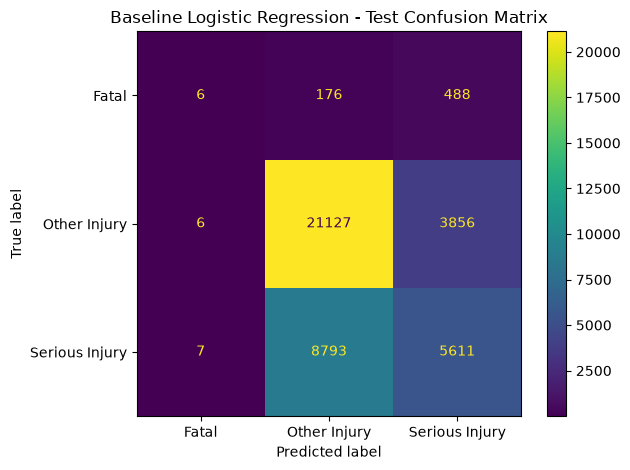

In [11]:
# Generate test predictions
y_test_pred = baseline_model.predict(X_test_selected)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[
        "Fatal",
        "Other Injury",
        "Serious Injury"
    ],
    values_format="d"
)

plt.title("Baseline Logistic Regression - Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 9. Normalized Confusion Matrix

A normalized confusion matrix is also displayed to examine the proportion of each actual severity class that was correctly or incorrectly classified.

This is particularly useful when class sizes are highly unequal.

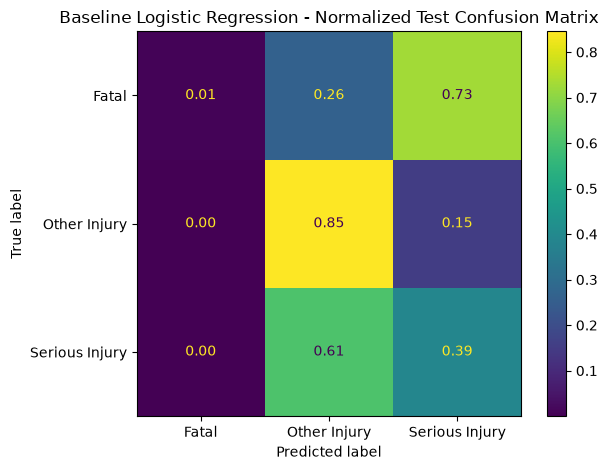

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[
        "Fatal",
        "Other Injury",
        "Serious Injury"
    ],
    normalize="true",
    values_format=".2f"
)

plt.title("Baseline Logistic Regression - Normalized Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Logistic Regression Coefficients

Multinomial Logistic Regression learns a separate coefficient set for each target class.

The coefficient values are inspected to understand which encoded features have stronger influence on the baseline model's decision boundaries.

Because categorical variables were one-hot encoded, coefficient names may contain category-specific values.

In [13]:
# Create coefficient table

coefficient_df = pd.DataFrame(
    baseline_model.coef_,
    index=[
        "Fatal",
        "Other Injury",
        "Serious Injury"
    ],
    columns=selected_encoded_feature_names
)

display(coefficient_df)

,POLICE_ATTEND_No,POLICE_ATTEND_Not known,POLICE_ATTEND_Yes,DCA_CODE,DCA_CODE_DESCRIPTION_ACCIDENT OR BROKEN DOWN,DCA_CODE_DESCRIPTION_ANY MANOEUVRE INVOLVING PED NOT INCLUDED IN DCAs 100-108.,DCA_CODE_DESCRIPTION_CROSS TRAFFIC(INTERSECTIONS ONLY),DCA_CODE_DESCRIPTION_CUTTING IN (OVERTAKING),DCA_CODE_DESCRIPTION_DOUBLE PARKED,DCA_CODE_DESCRIPTION_ENTERING PARKING,...,SPEED_ZONE_Camping grounds or off road,SPEED_ZONE_Not known,SPEED_ZONE_Other speed limit,OLD_DRIVER_75_AND_OVER,TOTAL_PERSONS,OLD_PED_65_AND_OVER,FEMALES,BICYCLIST,MALES,ROAD_NAME_FREQ
Fatal,-1.686142,-0.132254,0.321456,0.056320,0.003897,-0.084813,0.310446,0.006153,0.186162,-0.289987,...,-0.180277,-0.359478,-0.752723,0.119459,-0.489979,0.111815,0.322458,-0.002293,0.526465,-0.001453
Other Injury,1.198136,0.230528,-0.485434,-0.063592,-0.106224,-0.028819,-0.190880,0.096324,0.176568,0.246667,...,0.175573,0.269706,0.720843,-0.125931,0.301797,-0.107167,-0.241849,-0.059640,-0.371231,-0.000733
Serious Injury,0.488006,-0.098274,0.163977,0.007272,0.102327,0.113632,-0.119566,-0.102478,-0.362730,0.043320,...,0.004703,0.089772,0.031880,0.006472,0.188182,-0.004648,-0.080609,0.061933,-0.155234,0.002186


## 11. Top Coefficients by Class

To make the coefficient results easier to interpret, the features with the largest absolute coefficients are displayed for each severity class.

The absolute coefficient magnitude is used to identify features that have a stronger influence on the model's decision boundary.

In [14]:
# Display top 15 coefficients for each class

for class_name in coefficient_df.index:

    class_coefficients = (
        coefficient_df.loc[class_name]
        .sort_values(key=np.abs, ascending=False)
        .head(15)
    )

    print(f"\nTop coefficients for {class_name}:")
    display(
        class_coefficients.to_frame(
            name="Coefficient"
        )
    )


Top coefficients for Fatal:


,Coefficient
POLICE_ATTEND_No,-1.686142
DEG_URBAN_NAME_Missing,-1.386413
DCA_CODE_DESCRIPTION_HEAD ON (NOT OVERTAKING),1.174692
DCA_CODE_DESCRIPTION_HEAD ON(OVERTAKING),1.009527
DCA_CODE_DESCRIPTION_OTHER ON PATH,0.926980
RUN_OFFROAD_No,-0.879758
DCA_CODE_DESCRIPTION_STRUCK TRAIN,0.865075
DEG_URBAN_NAME_MELBOURNE_CBD,-0.807370
SPEED_ZONE_40 km/hr,-0.773777
DCA_CODE_DESCRIPTION_PED WALKING AGAINST TRAFFIC.,0.756859



Top coefficients for Other Injury:


,Coefficient
LONGITUDE,1.634620
VICGRID_X,-1.585325
LATITUDE,1.471652
VICGRID_Y,-1.466945
POLICE_ATTEND_No,1.198136
DCA_CODE_DESCRIPTION_HEAD ON (NOT OVERTAKING),-0.912340
DCA_CODE_DESCRIPTION_STRUCK TRAIN,-0.831511
SPEED_ZONE_Other speed limit,0.720843
DCA_CODE_DESCRIPTION_HEAD ON(OVERTAKING),-0.718591
DCA_CODE_DESCRIPTION_OTHER ON PATH,-0.645209



Top coefficients for Serious Injury:


,Coefficient
LATITUDE,-1.549496
VICGRID_Y,1.487992
LONGITUDE,-1.350370
VICGRID_X,1.334949
DEG_URBAN_NAME_Missing,0.892256
POLICE_ATTEND_No,0.488006
DCA_CODE_DESCRIPTION_PARKED VEHICLES ONLY,-0.394152
DCA_CODE_DESCRIPTION_REVERSING INTO FIXED OBJECT/PARKED VEHICLE,-0.391150
DCA_CODE_DESCRIPTION_LEFT/RIGHT FAR (INTERSECTIONS ONLY),0.383121
DCA_CODE_DESCRIPTION_PED EMERGES FROM IN FRONT OF PARKED OR STATIONARY VEHICLE,0.366997


## 12. Coefficient Visualization

The strongest coefficients for each severity class are visualized.

These plots provide an interpretable view of how the baseline Logistic Regression model associates selected crash characteristics with each accident severity category.

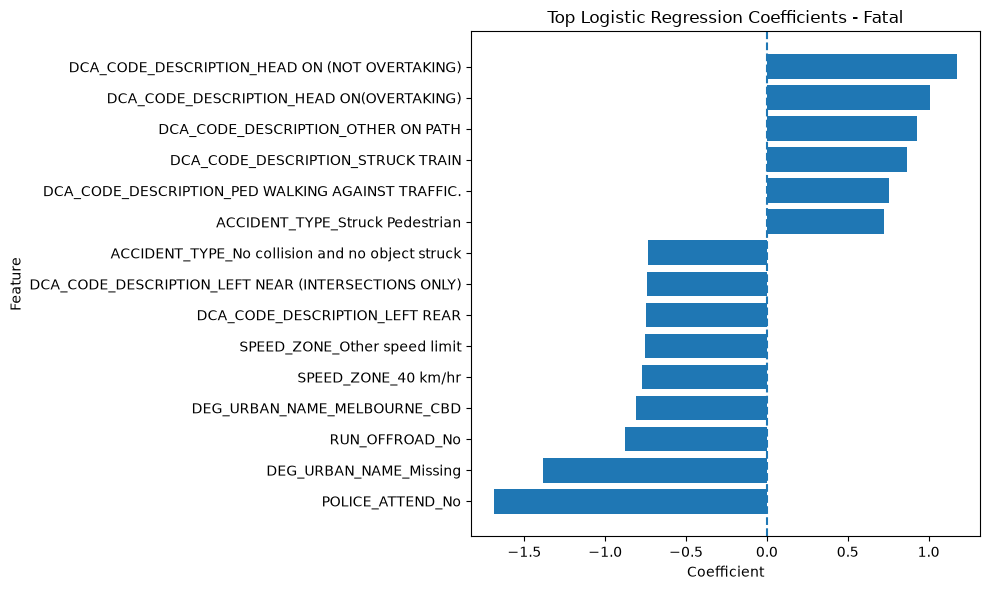

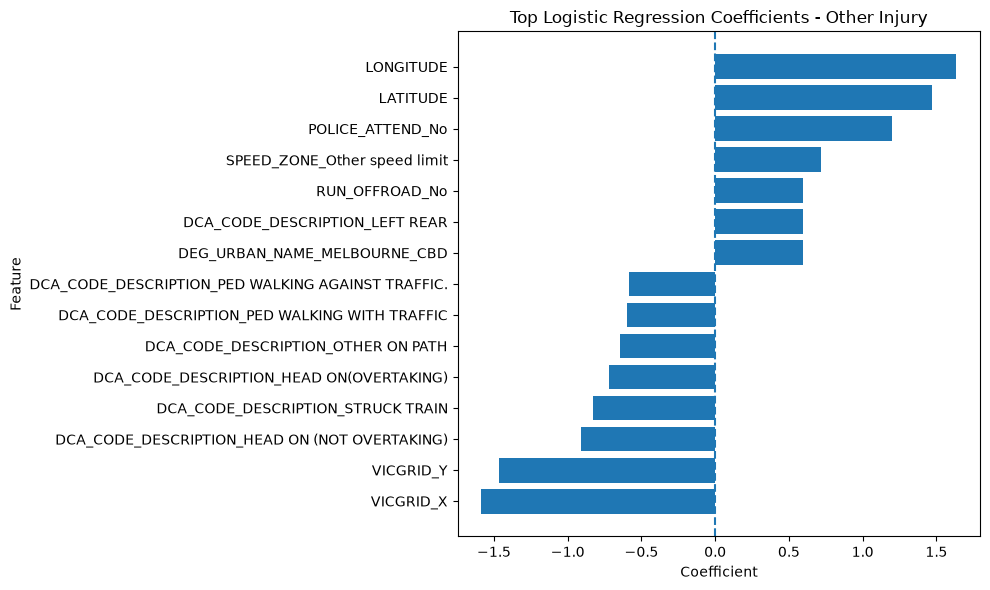

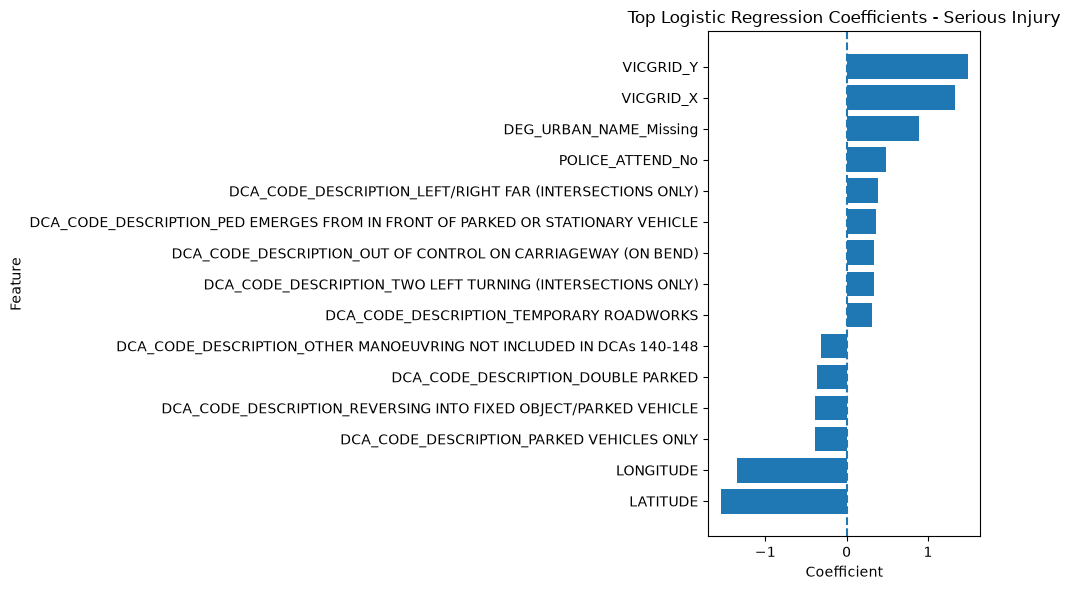

In [15]:
# Plot top 15 coefficients for each class

for class_name in coefficient_df.index:

    plot_df = (
        coefficient_df.loc[class_name]
        .sort_values(key=np.abs, ascending=False)
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_df.index,
        plot_df.values
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(
        f"Top Logistic Regression Coefficients - {class_name}"
    )

    plt.tight_layout()
    plt.show()

## 13. Baseline Model Summary

The baseline Logistic Regression model provides the initial performance reference for accident severity prediction.

The model uses the features selected through Information Gain, represented by their corresponding encoded columns.

No class-imbalance handling or extensive hyperparameter tuning is applied at this stage.

The results will be used as a reference for subsequent experiments involving class-imbalance handling and more advanced classification models.

In [16]:
# Display final baseline summary

print("BASELINE MODEL SUMMARY")
print("=" * 60)

print("Model: Multinomial Logistic Regression")
print("Original selected features:", len(selected_feature_names))
print("Encoded model features:", len(selected_encoded_feature_names))
print("Training samples:", X_train_selected.shape[0])
print("Testing samples:", X_test_selected.shape[0])

print("\nTest Performance:")
print(
    baseline_evaluation[
        baseline_evaluation["Dataset"] == "Test"
    ].drop(columns=["Dataset"]).T
)

BASELINE MODEL SUMMARY
Model: Multinomial Logistic Regression
Original selected features: 26
Encoded model features: 136
Training samples: 160278
Testing samples: 40070

Test Performance:
                        1
Accuracy         0.667432
Precision_Macro  0.527138
Recall_Macro     0.414588
F1_Macro         0.415015
ROC_AUC_Macro    0.766439


## 14. Interpretation of Baseline Results

### Model Performance

The baseline Logistic Regression model provides a reference performance for the accident severity classification task.

The test-set accuracy, macro precision, macro recall, macro F1-score, and macro ROC-AUC are considered together because the target classes are imbalanced.

### Class-wise Performance

The classification report and confusion matrix are examined to determine how effectively the model identifies Fatal, Other Injury, and Serious Injury accidents.

Particular attention is given to the Fatal class because it represents the minority class in the dataset.

### Generalization

Training and test performance are compared to identify any substantial difference between the model's performance on known training data and unseen test data.

### Baseline Limitation

The baseline model does not use class-imbalance handling or extensive hyperparameter tuning. Therefore, its results serve as a reference point rather than the final model performance.

Subsequent experiments will investigate whether imbalance-handling techniques and more flexible machine learning models can improve classification performance, particularly for the minority Fatal class.

In [17]:
# Save baseline evaluation results for later model comparison

baseline_results_path = data_dir / "baseline_logistic_regression_results.csv"

baseline_evaluation.to_csv(
    baseline_results_path,
    index=False
)

print("Baseline results saved to:")
print(baseline_results_path)

Baseline results saved to:
..\data\baseline_logistic_regression_results.csv


In [18]:
# Save the trained baseline model

import joblib

baseline_model_path = data_dir / "baseline_logistic_regression.pkl"

joblib.dump(
    baseline_model,
    baseline_model_path
)

print("Baseline model saved to:")
print(baseline_model_path)

Baseline model saved to:
..\data\baseline_logistic_regression.pkl
